# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [6]:
monthly_mean = df['count'].resample('ME').mean()

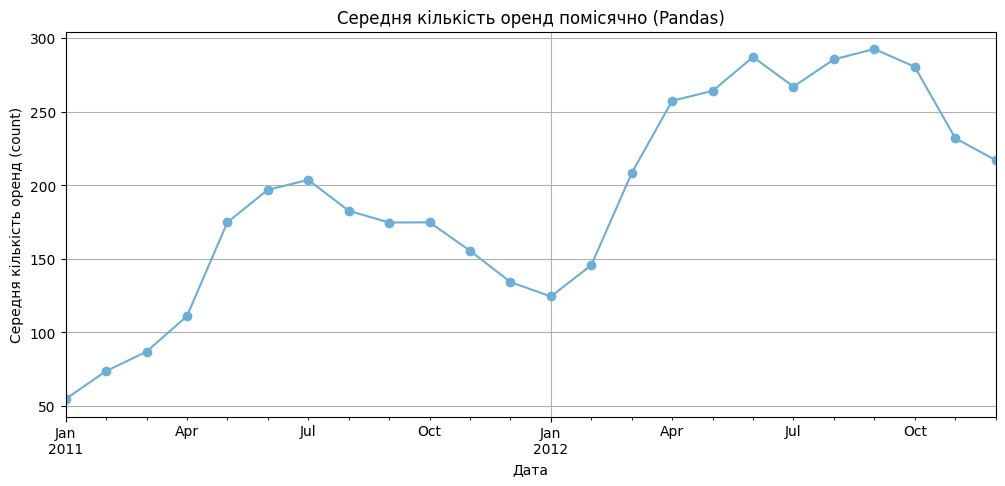

In [10]:
ax = monthly_mean.plot(
    kind='line',
    marker='o',
    color='#6BAED6',
    figsize=(12, 5),
    title='Середня кількість оренд помісячно (Pandas)'
)

ax.set_xlabel('Дата')
ax.set_ylabel('Середня кількість оренд (count)')
ax.grid(True)




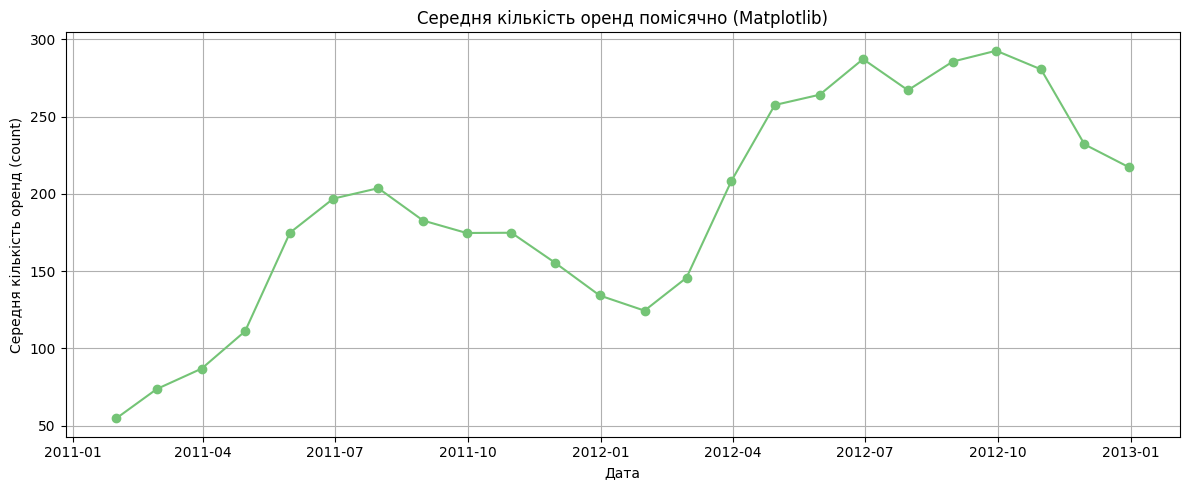

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_mean.index,
    monthly_mean.values,
    marker='o',
    color='#74C476'
)
plt.title('Середня кількість оренд помісячно (Matplotlib)')
plt.xlabel('Дата')
plt.ylabel('Середня кількість оренд (count)')
plt.grid(True)
plt.tight_layout()
plt.show()


Висновок:

Обидва графіки відображають однакові дані, але різниця полягає в способі побудови:

Графік через Pandas створюється простіше та швидше, код є коротшим.

Графік через Matplotlib дає більше контролю над оформленням (формат осей, стиль, додаткові налаштування).

Мені більше подобається варіант з Matplotlib, оскільки він надає більше можливостей для гнучкого налаштування зовнішнього вигляду графіка.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [11]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень2

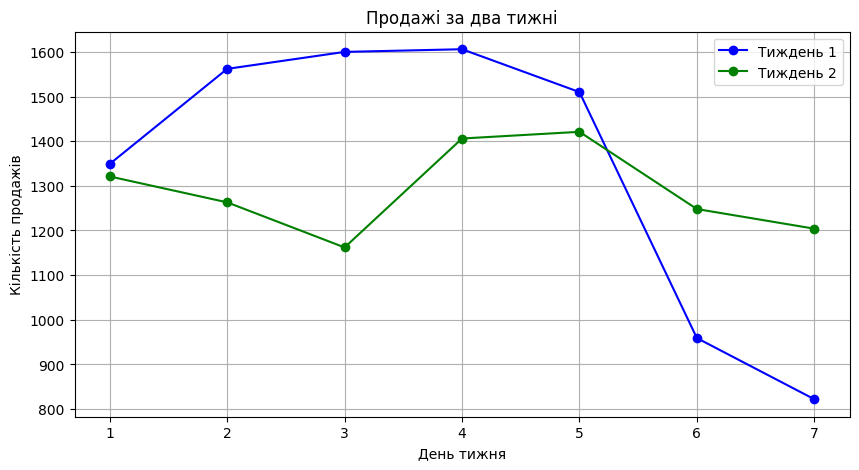

In [12]:
plt.figure(figsize=(10,5))

plt.plot(days, sales_week1, marker='o', color='blue', label='Тиждень 1')
plt.plot(days, sales_week2, marker='o', color='green', label='Тиждень 2')

plt.title('Продажі за два тижні')
plt.xlabel('День тижня')
plt.ylabel('Кількість продажів')
plt.xticks(days)
plt.legend()
plt.grid(True)

plt.show()



Висновки:

1️. В який тиждень продажі були стабільніші?

Продажі були стабільнішими у другому тижні, оскільки коливання значень протягом тижня менші.
У першому тижні спостерігається різке падіння продажів на 6–7 день.

2️. Чи можна підтвердити обчисленнями?

Так, можна використати стандартне відхилення або діапазон (max−min).
У першому тижні розмах значень значно більший (від 822 до 1606). У другому тижні коливання менші (від 1162 до 1421). Менше стандартне відхилення - більша стабільність. Обчислення підтверджують, що другий тиждень стабільніший.

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

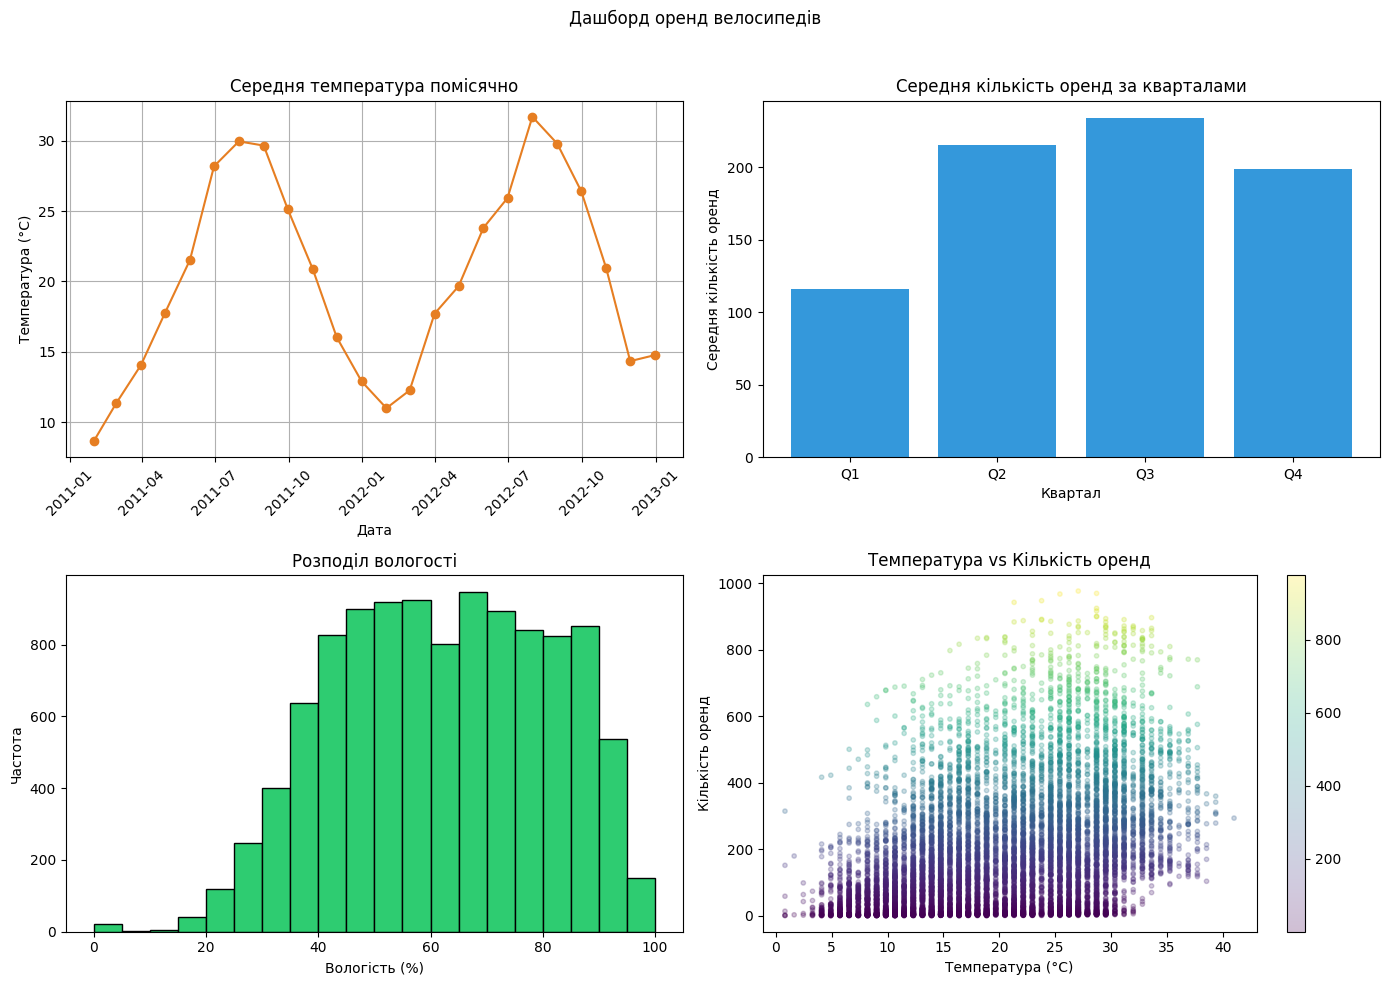

In [17]:
plt.figure(figsize=(14,10))

#Температура помісячно
plt.subplot(2,2,1)
monthly_temp = df['temp'].resample('ME').mean()
plt.plot(monthly_temp.index,
         monthly_temp.values,
         marker='o',
         color='#E67E22')
plt.title('Середня температура помісячно')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.xticks(rotation=45)
plt.grid(True)


#Оренди за кварталами
plt.subplot(2,2,2)
quarter_mean = df.groupby('season')['count'].mean()
plt.bar(['Q1','Q2','Q3','Q4'],
        quarter_mean.values,
        color='#3498DB')
plt.title('Середня кількість оренд за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Середня кількість оренд')


#Гістограма вологості
plt.subplot(2,2,3)
plt.hist(df['humidity'],
         bins=20,
         color='#2ECC71',
         edgecolor='black')
plt.title('Розподіл вологості')
plt.xlabel('Вологість (%)')
plt.ylabel('Частота')


#Scatter
plt.subplot(2,2,4)
sc = plt.scatter(df['temp'],
                 df['count'],
                 alpha=0.25,
                 c=df['count'],
                 cmap='viridis',
                 s=10)
plt.title('Температура vs Кількість оренд')
plt.xlabel('Температура (°C)')
plt.ylabel('Кількість оренд')
plt.colorbar(sc)

plt.suptitle('Дашборд оренд велосипедів')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

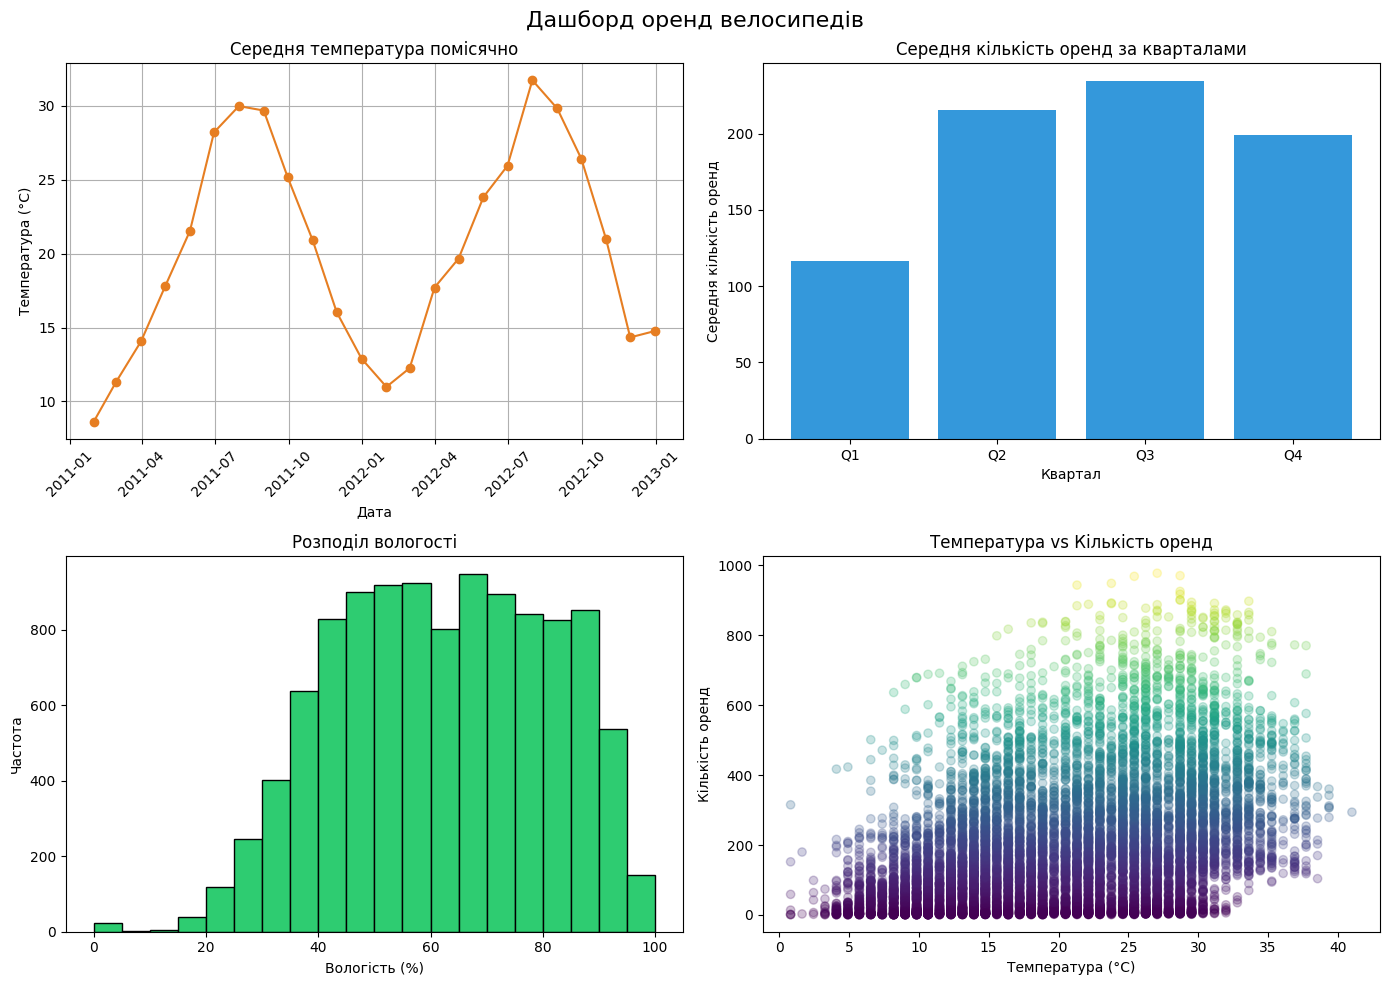

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(14,10))

#Температура помісячно
monthly_temp = df['temp'].resample('ME').mean()

ax[0,0].plot(monthly_temp.index,
             monthly_temp.values,
             marker='o',
             color='#E67E22')

ax[0,0].set_title('Середня температура помісячно')
ax[0,0].set_xlabel('Дата')
ax[0,0].set_ylabel('Температура (°C)')
ax[0,0].tick_params(axis='x', rotation=45)
ax[0,0].grid(True)


#Оренди за кварталами
quarter_mean = df.groupby('season')['count'].mean()

ax[0,1].bar(['Q1','Q2','Q3','Q4'],
            quarter_mean.values,
            color='#3498DB')

ax[0,1].set_title('Середня кількість оренд за кварталами')
ax[0,1].set_xlabel('Квартал')
ax[0,1].set_ylabel('Середня кількість оренд')


#Гістограма вологості
ax[1,0].hist(df['humidity'],
             bins=20,
             color='#2ECC71',
             edgecolor='black')

ax[1,0].set_title('Розподіл вологості')
ax[1,0].set_xlabel('Вологість (%)')
ax[1,0].set_ylabel('Частота')


#Scatter: температура vs оренди
ax[1,1].scatter(df['temp'],
                df['count'],
                alpha=0.25,
                c=df['count'],
                cmap='viridis')

ax[1,1].set_title('Температура vs Кількість оренд')
ax[1,1].set_xlabel('Температура (°C)')
ax[1,1].set_ylabel('Кількість оренд')


plt.suptitle('Дашборд оренд велосипедів', fontsize=16)
plt.tight_layout()
plt.show()

Висновок:
Різниця двох підходів побудови графіків в тому, що subplots() дає більше контролю і виглядає акуратніше, а subplot() — простіший, але менш гнучкий.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?